# Real Data Fall Detection Model
**Pipeline:** Load → Clean → Feature Extraction → RF Training → ESP32 Export

| Label | Value | Duration |
|-------|-------|----------|
| NORMAL | 0 | 30s |
| FALLING | 1 | 5s |
| FALLEN | 2 | 10s |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from micromlgen import port
import warnings, os
warnings.filterwarnings('ignore')

DATA_DIR   = '../data_lable/'
MODEL_DIR  = 'models/esp32/'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Window params ─────────────────────────────────────────────
WINDOW    = 50    # 1 second at 50Hz
STRIDE    = 5     # 0.1s step
FS        = 50.0
TRANS_BUF = 10    # ±0.2s transition buffer

# ── RF: ขนาดเล็กพอ ESP32 (<200KB) ────────────────────────────
# n=20, max_leaf=60 → ~150KB based on previous models
RF_PARAMS = dict(
    n_estimators    = 20,
    max_depth       = 10,
    max_leaf_nodes  = 60,
    min_samples_leaf= 3,
    class_weight    = {0: 1, 1: 8, 2: 2},  # FALLING weight สูงมาก
    random_state    = 42,
    n_jobs          = -1
)

print('Libraries loaded ✓')
print(f'Window={WINDOW}  Stride={STRIDE}  n_trees={RF_PARAMS["n_estimators"]}  max_leaf={RF_PARAMS["max_leaf_nodes"]}')

Libraries loaded ✓
Window=50  Stride=5  n_trees=20  max_leaf=60


## 1. Load & Clean Data

In [2]:
def load_and_clean(filepath, mode_name):
    df = pd.read_csv(filepath, comment='#', header=None)
    df.columns = ['ms','ax','ay','az','label','mode']
    
    print(f'\n=== {mode_name} raw: {len(df)} samples ===')
    
    # ── Step 1: Remove I2C glitch outliers
    mag = np.sqrt(df.ax**2 + df.ay**2 + df.az**2)
    outlier_mask = (mag < 2.0) | (mag > 40.0)
    df = df[~outlier_mask].reset_index(drop=True)
    print(f'  Outlier removed: {outlier_mask.sum()}')
    
    # ── Step 2: Drop first NORMAL segment (calibration + person adjusting)
    seg = (df.label != df.label.shift()).cumsum()
    first_seg = seg[seg == 1].index
    df = df.drop(first_seg).reset_index(drop=True)
    
    # ── Step 3: Remove ±TRANS_BUF samples around label transitions
    transitions = df[df.label.diff().abs() > 0].index.tolist()
    bad_idx = set()
    for t in transitions:
        for i in range(max(0, t - TRANS_BUF), min(len(df), t + TRANS_BUF)):
            bad_idx.add(i)
    df = df.drop(list(bad_idx)).reset_index(drop=True)
    print(f'  Transition buffer removed: {len(bad_idx)}')
    
    # ── NO software low-pass filter ──────────────────────────────
    # MPU6050 hardware DLPF=21Hz already handles electronic noise
    # Applying 10Hz SW filter removes the high-freq FALLING signal
    
    # ── Step 4: Assign loop ID for CV
    seg2 = (df.label != df.label.shift()).cumsum()
    df['loop_id'] = ((seg2 - 1) // 3).values
    
    counts = df.label.value_counts().sort_index().to_dict()
    print(f'  Final: {len(df)} samples | {counts} | loops={df.loop_id.nunique()}')
    return df

files = {
    'CHEST': DATA_DIR + 'chest_lable_1.txt',
    'SHIRT': DATA_DIR + 'shirt_lable_1.txt',
    'PANTS': DATA_DIR + 'pants_lable_1.txt',
}
dfs = {name: load_and_clean(path, name) for name, path in files.items()}


=== CHEST raw: 13745 samples ===
  Outlier removed: 0
  Transition buffer removed: 320
  Final: 12053 samples | {0: 7809, 1: 1377, 2: 2867} | loops=6

=== SHIRT raw: 11045 samples ===
  Outlier removed: 0
  Transition buffer removed: 260
  Final: 9414 samples | {0: 5877, 1: 1147, 2: 2390} | loops=5

=== PANTS raw: 11045 samples ===
  Outlier removed: 0
  Transition buffer removed: 260
  Final: 9414 samples | {0: 5876, 1: 1148, 2: 2390} | loops=5


## 2. Visualize Clean Data

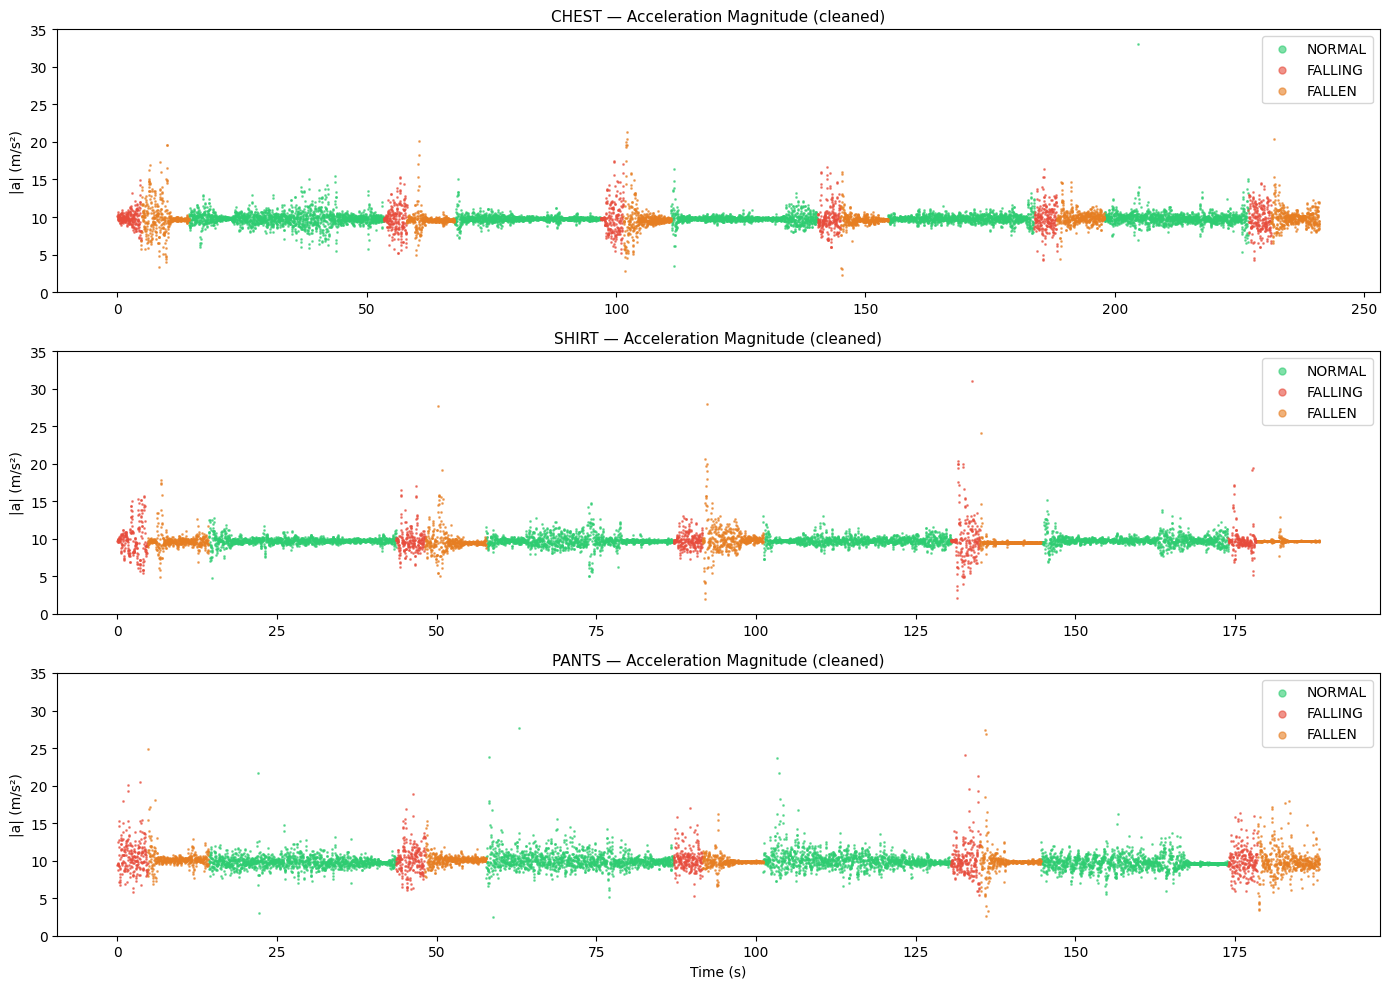

In [3]:
colors = {0: '#2ecc71', 1: '#e74c3c', 2: '#e67e22'}
label_names = {0:'NORMAL', 1:'FALLING', 2:'FALLEN'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, (name, df) in zip(axes, dfs.items()):
    mag = np.sqrt(df.ax**2 + df.ay**2 + df.az**2)
    t = np.arange(len(df)) / FS
    for lbl in [0,1,2]:
        mask = df.label == lbl
        ax.scatter(t[mask], mag[mask], c=colors[lbl], s=1, label=label_names[lbl], alpha=0.6)
    ax.set_title(f'{name} — Acceleration Magnitude (cleaned)', fontsize=11)
    ax.set_ylabel('|a| (m/s²)')
    ax.set_ylim(0, 35)
    ax.legend(markerscale=5, loc='upper right')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('realdata_overview.png', dpi=120)
plt.show()

## 3. Feature Extraction

In [4]:
def extract_features(window_ax, window_ay, window_az):
    """
    22 features — NO pre-filtering (hardware DLPF 21Hz is enough)
    ออกแบบเพื่อจับ FALLING (เหวี่ยงไปมา = high jerk + high mag variance)
    """
    mag = np.sqrt(window_ax**2 + window_ay**2 + window_az**2)
    
    # Jerk (rate of acceleration change) — สำคัญสุดสำหรับ FALLING
    jerk_x = np.diff(window_ax)
    jerk_y = np.diff(window_ay)
    jerk_z = np.diff(window_az)
    jerk_mag = np.sqrt(jerk_x**2 + jerk_y**2 + jerk_z**2)
    
    # IQR of magnitude (robust variance — ไม่ถูก outlier รบกวน)
    q75, q25 = np.percentile(mag, [75, 25])
    mag_iqr = q75 - q25
    
    # Skewness of magnitude (FALLING มี asymmetric distribution)
    mag_mean = np.mean(mag)
    mag_std  = np.std(mag)
    mag_skew = np.mean(((mag - mag_mean) / (mag_std + 1e-8))**3)
    
    # Count samples with extreme G (FALLING มักมี impact peak > 2g = 19.6)
    frac_high_g = np.mean(mag > 19.6)
    frac_low_g  = np.mean(mag < 4.9)   # freefall < 0.5g
    
    feats = [
        # Axis means (gravity orientation — ช่วย FALLEN vs NORMAL)
        np.mean(window_ax), np.mean(window_ay), np.mean(window_az),
        # Axis stds (movement amount per axis)
        np.std(window_ax), np.std(window_ay), np.std(window_az),
        # Magnitude stats
        mag_mean, mag_std, np.max(mag), np.min(mag), mag_iqr,
        # Jerk (FALLING มีสูง)
        np.mean(jerk_mag), np.max(jerk_mag), np.std(jerk_mag),
        # Energy
        np.sum(window_ax**2 + window_ay**2 + window_az**2) / len(window_ax),
        # Peak-to-peak
        np.max(mag) - np.min(mag),
        # Cross-axis correlation
        np.corrcoef(window_ax, window_az)[0, 1],
        np.corrcoef(window_ay, window_az)[0, 1],
        # Distribution shape
        mag_skew,
        # Extreme G fractions
        frac_high_g, frac_low_g,
        # Jerk energy (FALLING = rapid direction changes)
        np.sum(jerk_mag**2) / len(jerk_mag),
    ]
    return [0.0 if np.isnan(f) else float(f) for f in feats]

N_FEATURES = len(extract_features(np.ones(WINDOW), np.ones(WINDOW), np.ones(WINDOW)))
print(f'Features per window: {N_FEATURES}')

def make_windows(df):
    X, y, loop_ids = [], [], []
    ax = df.ax.values; ay = df.ay.values; az = df.az.values
    labels = df.label.values; loops = df.loop_id.values
    
    for start in range(0, len(df) - WINDOW + 1, STRIDE):
        end = start + WINDOW
        win_labels = labels[start:end]
        if len(np.unique(win_labels)) > 1:
            continue
        feats = extract_features(ax[start:end], ay[start:end], az[start:end])
        X.append(feats)
        y.append(win_labels[0])
        loop_ids.append(int(np.median(loops[start:end])))
    
    return np.array(X), np.array(y), np.array(loop_ids)

print('Extracting windows...')
windows = {}
for name, df in dfs.items():
    X, y, loops = make_windows(df)
    windows[name] = (X, y, loops)
    counts = {int(k): int(v) for k,v in zip(*np.unique(y, return_counts=True))}
    print(f'  {name}: {len(X)} windows | {counts}')
print(f'\n{N_FEATURES} features each.')

Features per window: 22
Extracting windows...


  CHEST: 2246 windows | {0: 1514, 1: 218, 2: 514}


  SHIRT: 1747 windows | {0: 1137, 1: 181, 2: 429}
  PANTS: 1747 windows | {0: 1136, 1: 182, 2: 429}

22 features each.


## 4. Train — Leave-One-Loop-Out Cross Validation

In [5]:
def lolo_cv(X, y, loops, mode_name):
    """Leave-One-Loop-Out CV: train on N-1 loops, test on 1"""
    unique_loops = np.unique(loops)
    all_true, all_pred = [], []

    print(f'\n── {mode_name} LOLO-CV ({len(unique_loops)} loops) ──')
    for test_loop in unique_loops:
        train_mask = loops != test_loop
        test_mask  = loops == test_loop
        X_train, y_train = X[train_mask], y[train_mask]
        X_test,  y_test  = X[test_mask],  y[test_mask]

        clf = RandomForestClassifier(**RF_PARAMS)
        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)
        f1 = f1_score(y_test, pred, average='macro')
        fall_f1 = f1_score(y_test, pred, labels=[1], average='macro')
        print(f'  Loop {test_loop}: macro-F1={f1:.3f}  FALLING-F1={fall_f1:.3f}')
        all_true.extend(y_test)
        all_pred.extend(pred)

    print(f'\nOverall:')
    print(classification_report(all_true, all_pred, target_names=['NORMAL','FALLING','FALLEN']))
    return np.array(all_true), np.array(all_pred)

cv_results = {}
for name in ['CHEST','SHIRT','PANTS']:
    X, y, loops = windows[name]
    true, pred = lolo_cv(X, y, loops, name)
    cv_results[name] = (true, pred)


── CHEST LOLO-CV (6 loops) ──


  Loop 0: macro-F1=0.371  FALLING-F1=0.000
  Loop 1: macro-F1=0.884  FALLING-F1=0.831
  Loop 2: macro-F1=0.895  FALLING-F1=0.761
  Loop 3: macro-F1=0.944  FALLING-F1=0.875


  Loop 4: macro-F1=0.556  FALLING-F1=0.736


  Loop 5: macro-F1=0.532  FALLING-F1=0.912

Overall:
              precision    recall  f1-score   support

      NORMAL       0.87      0.82      0.85      1514
     FALLING       0.50      0.67      0.57       218
      FALLEN       0.70      0.71      0.70       514

    accuracy                           0.78      2246
   macro avg       0.69      0.73      0.71      2246
weighted avg       0.79      0.78      0.79      2246


── SHIRT LOLO-CV (5 loops) ──
  Loop 0: macro-F1=0.635  FALLING-F1=0.761
  Loop 1: macro-F1=0.633  FALLING-F1=0.560
  Loop 2: macro-F1=0.562  FALLING-F1=0.379
  Loop 3: macro-F1=0.606  FALLING-F1=0.033


  Loop 4: macro-F1=0.545  FALLING-F1=0.714

Overall:
              precision    recall  f1-score   support

      NORMAL       0.88      0.89      0.89      1137
     FALLING       0.51      0.52      0.52       181
      FALLEN       0.67      0.62      0.65       429

    accuracy                           0.79      1747
   macro avg       0.69      0.68      0.68      1747
weighted avg       0.79      0.79      0.79      1747


── PANTS LOLO-CV (5 loops) ──


  Loop 0: macro-F1=0.816  FALLING-F1=0.516
  Loop 1: macro-F1=0.783  FALLING-F1=0.558
  Loop 2: macro-F1=0.588  FALLING-F1=0.000
  Loop 3: macro-F1=0.666  FALLING-F1=0.149
  Loop 4: macro-F1=0.629  FALLING-F1=0.899

Overall:
              precision    recall  f1-score   support

      NORMAL       0.90      0.91      0.90      1136
     FALLING       0.45      0.45      0.45       182
      FALLEN       0.95      0.93      0.94       429

    accuracy                           0.86      1747
   macro avg       0.77      0.76      0.76      1747
weighted avg       0.87      0.86      0.86      1747



## 5. Confusion Matrix

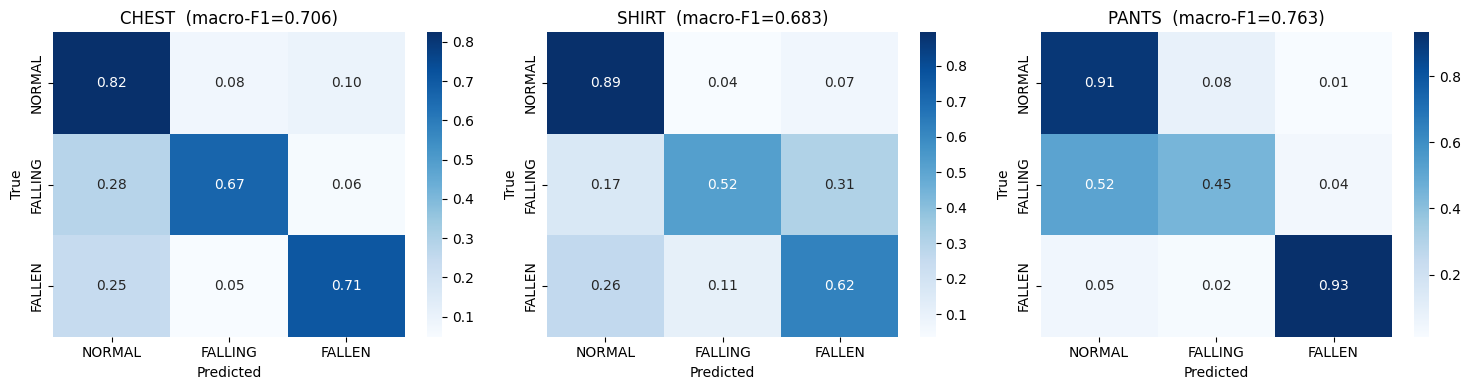

In [6]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
label_names_list = ['NORMAL','FALLING','FALLEN']

for ax, (name, (true, pred)) in zip(axes, cv_results.items()):
    cm = confusion_matrix(true, pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=label_names_list, yticklabels=label_names_list, ax=ax)
    f1 = f1_score(true, pred, average='macro')
    ax.set_title(f'{name}  (macro-F1={f1:.3f})')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('realdata_confusion.png', dpi=120)
plt.show()

## 6. Feature Importance

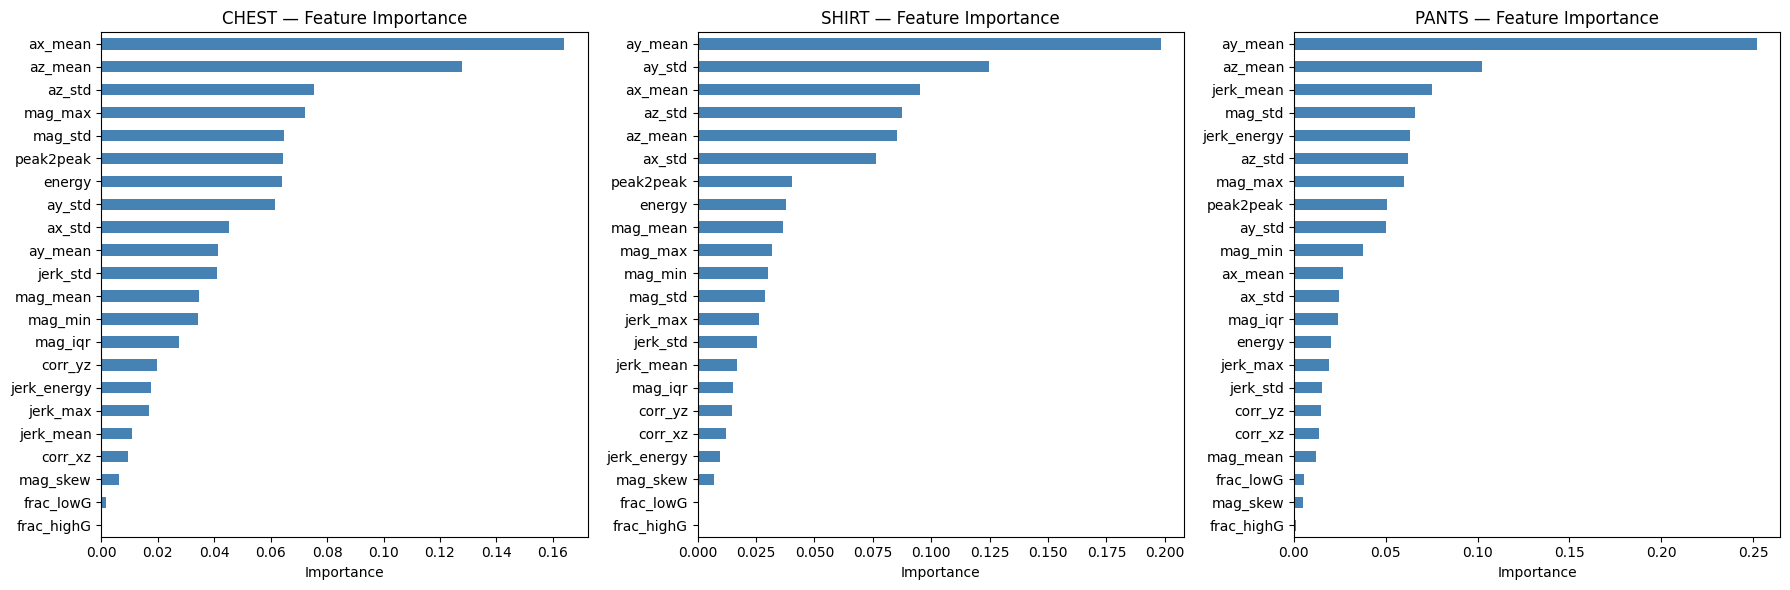

In [7]:
feature_names = [
    'ax_mean','ay_mean','az_mean',
    'ax_std', 'ay_std', 'az_std',
    'mag_mean','mag_std','mag_max','mag_min','mag_iqr',
    'jerk_mean','jerk_max','jerk_std',
    'energy','peak2peak',
    'corr_xz','corr_yz',
    'mag_skew','frac_highG','frac_lowG','jerk_energy'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name in zip(axes, ['CHEST','SHIRT','PANTS']):
    X, y, _ = windows[name]
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X, y)
    imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values()
    imp.plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'{name} — Feature Importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('realdata_importance.png', dpi=120)
plt.show()

## 7. Train Final Models (All Loops) + Export to ESP32

In [8]:
CLASS_NAMES = {
    'CHEST': 'FallDetectorChest',
    'SHIRT': 'FallDetectorShirt',
    'PANTS': 'FallDetectorPants',
}

def train_final(name):
    X, y, _ = windows[name]
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X, y)

    clf_code = port(clf,
                    classname=CLASS_NAMES[name],
                    classmap={0:'NORMAL', 1:'FALLING', 2:'FALLEN'})
    out_path = f'{MODEL_DIR}{name}_model.h'
    with open(out_path, 'w') as f:
        f.write(clf_code)

    size_kb   = os.path.getsize(out_path) / 1024
    train_f1  = f1_score(y, clf.predict(X), average='macro')
    print(f'{name} ({CLASS_NAMES[name]}): {len(X)} windows | trainF1={train_f1:.3f} | {size_kb:.0f}KB')
    return clf

print(f'Training final models...\n')
final_models = {name: train_final(name) for name in ['CHEST','SHIRT','PANTS']}
print('\n✓ Exported to', MODEL_DIR)

Training final models...

CHEST (FallDetectorChest): 2246 windows | trainF1=0.981 | 331KB
SHIRT (FallDetectorShirt): 1747 windows | trainF1=0.979 | 240KB
PANTS (FallDetectorPants): 1747 windows | trainF1=0.988 | 247KB

✓ Exported to models/esp32/


## 8. Summary & ESP32 Integration Guide

In [9]:
print('=' * 60)
print('CROSS-VALIDATION SUMMARY')
print('=' * 60)
for name, (true, pred) in cv_results.items():
    report = classification_report(true, pred,
                                   target_names=['NORMAL','FALLING','FALLEN'],
                                   output_dict=True)
    print(f'\n{name}:')
    for lbl in ['NORMAL','FALLING','FALLEN']:
        r = report[lbl]
        print(f'  {lbl:<8} P={r["precision"]:.2f}  R={r["recall"]:.2f}  F1={r["f1-score"]:.2f}')
    print(f'  Macro-F1 = {report["macro avg"]["f1-score"]:.3f}')

print('''
═══════════════════════════════════════════════════════════
ESP32 INTEGRATION — คัดลอกไปใส่ Full_System_README.ino
═══════════════════════════════════════════════════════════

Features (ต้องคำนวณแบบเดียวกัน — window 50 samples):
  feat[0]  = ax_mean       feat[6]  = mag_mean
  feat[1]  = ay_mean       feat[7]  = mag_std
  feat[2]  = az_mean       feat[8]  = mag_max
  feat[3]  = ax_std        feat[9]  = mag_min
  feat[4]  = ay_std        feat[10] = jerk_mean
  feat[5]  = az_std        feat[11] = jerk_max
  feat[12] = energy        feat[13] = peak2peak
  feat[14] = corr_xz       feat[15] = corr_yz
  feat[16] = frac_highG    feat[17] = frac_lowG
''')

CROSS-VALIDATION SUMMARY

CHEST:
  NORMAL   P=0.87  R=0.82  F1=0.85
  FALLING  P=0.50  R=0.67  F1=0.57
  FALLEN   P=0.70  R=0.71  F1=0.70
  Macro-F1 = 0.706

SHIRT:
  NORMAL   P=0.88  R=0.89  F1=0.89
  FALLING  P=0.51  R=0.52  F1=0.52
  FALLEN   P=0.67  R=0.62  F1=0.65
  Macro-F1 = 0.683



PANTS:
  NORMAL   P=0.90  R=0.91  F1=0.90
  FALLING  P=0.45  R=0.45  F1=0.45
  FALLEN   P=0.95  R=0.93  F1=0.94
  Macro-F1 = 0.763

═══════════════════════════════════════════════════════════
ESP32 INTEGRATION — คัดลอกไปใส่ Full_System_README.ino
═══════════════════════════════════════════════════════════

Features (ต้องคำนวณแบบเดียวกัน — window 50 samples):
  feat[0]  = ax_mean       feat[6]  = mag_mean
  feat[1]  = ay_mean       feat[7]  = mag_std
  feat[2]  = az_mean       feat[8]  = mag_max
  feat[3]  = ax_std        feat[9]  = mag_min
  feat[4]  = ay_std        feat[10] = jerk_mean
  feat[5]  = az_std        feat[11] = jerk_max
  feat[12] = energy        feat[13] = peak2peak
  feat[14] = corr_xz       feat[15] = corr_yz
  feat[16] = frac_highG    feat[17] = frac_lowG



## 9. Verify: Simulate ESP32 Inference on Test Window

In [10]:
# ── Pick a real FALLING window and verify prediction ──────────
for name in ['CHEST','SHIRT','PANTS']:
    X, y, _ = windows[name]
    clf = final_models[name]
    
    falling_idx = np.where(y == 1)[0]
    normal_idx  = np.where(y == 0)[0]
    fallen_idx  = np.where(y == 2)[0]
    
    print(f'{name}:')
    for lbl_name, idx in [('NORMAL', normal_idx[0]), 
                           ('FALLING', falling_idx[0]),
                           ('FALLEN', fallen_idx[0])]:
        pred_lbl = ['NORMAL','FALLING','FALLEN'][clf.predict(X[idx:idx+1])[0]]
        ok = '✓' if pred_lbl == lbl_name else '✗'
        print(f'  {ok} True={lbl_name:<8} Pred={pred_lbl}')
    print()

CHEST:
  ✓ True=NORMAL   Pred=NORMAL
  ✓ True=FALLING  Pred=FALLING
  ✓ True=FALLEN   Pred=FALLEN

SHIRT:
  ✓ True=NORMAL   Pred=NORMAL
  ✓ True=FALLING  Pred=FALLING
  ✓ True=FALLEN   Pred=FALLEN

PANTS:
  ✓ True=NORMAL   Pred=NORMAL
  ✓ True=FALLING  Pred=FALLING
  ✗ True=FALLEN   Pred=FALLING

